# Implementation of BLA initiliasation
Goal of this file is to obtain consistent NN models, using the BLA initialisation.
This is done in the following steps:

- Call the datagen to generate a dataset
- <font color='red'>(Optional) MATLAB hook to determine the BLA matrices for that dataset</font>
- Initialise the model with the BLA matrices
- Train the encoder for <font color='red'>(???)</font> epochs
- Freeze encoder parameters and enable NNs for J, R, G, P
- Train the NNs for <font color='red'>(???)</font> epochs
- Save the model and training information

These steps are then followed by a few visualization cells, showing the:
- Training and validation losses
- Qualitative simulation on a test set

In [1]:
# ========== Imports ==========
import os
import torch
import scipy
import numpy as np
import matlab.engine
import matplotlib.pyplot as plt

from MSD_model import combined_PHNN, cheat_PHNN, fit_model
from MSD_datagen import generate_data
from utils import *

# Indicate data locations
#PATH_MATRICES = "matlabIO/W19_BLA_matrices.mat"
PATH_DATASET = "datasets/W33_10SNR_3MSD_nonlinear_DS.pt"
PATH_TRAINED_ENC = "models/encoders/W33_TEMPSNR_combined_model_encoder.pt"
PATH_TRAINED_MODEL = "models/W33_TEMPSNR_combined_model.pt"

# Set figure parameters in advance
plt.rcParams['figure.figsize'] = (15, 3)
plt.rcParams['figure.facecolor'] = "eee8e8"
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

c:\Users\20174290\AppData\Local\miniconda3\envs\portHamiltonian\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Call the datagen to generate a dataset:

In [2]:
# System settings
sim_time = torch.linspace(0, 100, 1000)   # NOTE be careful of sim_time: [0, 100] for dataset, while [0, 1] for matlab
signal_to_noise_ratio = 10
M_vals = torch.FloatTensor([2, 2, 2])
D_vals = torch.FloatTensor([3, 3, 3])
K_vals = torch.FloatTensor([4, 4, 4])
cD_vals = torch.FloatTensor([1, 1, 1])

# Import or generate data
if os.path.isfile(PATH_DATASET):
    print(f"Loading dataset: {PATH_DATASET}")
    datasets = torch.load(PATH_DATASET, weights_only=False)
else:
    print(f"Generating dataset to: {PATH_DATASET}")
    datasets = generate_data(sim_time, M_vals=M_vals, D_vals=D_vals, K_vals=K_vals, cubic_D=cD_vals, n_datasets=8, SNR=signal_to_noise_ratio, freq_band=torch.linspace(0.1, 12, 40))
    torch.save(datasets, PATH_DATASET)

Generating dataset to: datasets/W33_10SNR_3MSD_nonlinear_DS.pt


### <font color='red'>(Optional)</font> MATLAB hook to determine the BLA matrices for that dataset:
Note that while the MATLAB matrices are carried over nicely (in terms of precision), their products differ slightly. </br>
For example: </br>
MATLAB ((J-R)*Q)[1, 1] = 12.4077328843393 </br>
PYTHON ((J-R)*Q)[1, 1] = 12.4075

tensor([[ 9.7656e-04, -2.4414e-04,  0.0000e+00,  0.0000e+00, -1.9073e-06,
          0.0000e+00],
        [-2.4414e-04,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.2207e-04,
          2.4414e-04],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00],
        [-1.9073e-06,  0.0000e+00,  1.2207e-04,  0.0000e+00,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  2.4414e-04,  0.0000e+00,  0.0000e+00,
          0.0000e+00]])
Given matrices: ['E', 'J', 'G', 'S', 'Q', 'R', 'P', 'N']


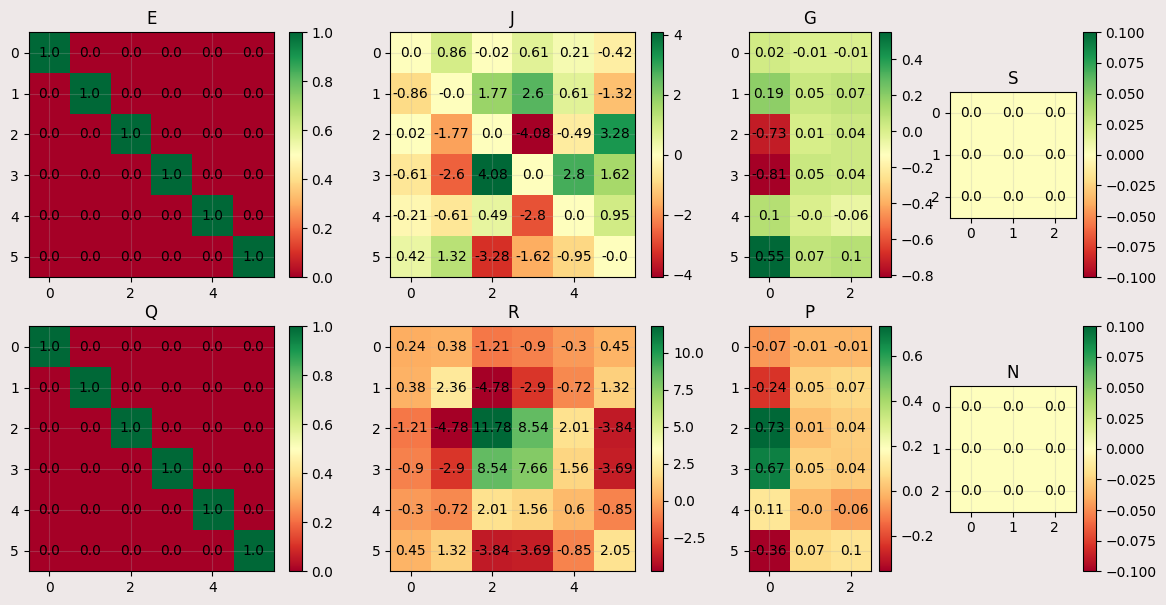

In [3]:
# ========== Automatic ==========
# Activate the matlab engine and provide access to the correct folder/script
eng = matlab.engine.start_matlab()
eng.cd(r'matlabIO', nargout=0)

# Convert the datasets to numpy arrays for processing in MATLAB
MATLAB_input_dict = {
    "sim_time": datasets[0]["sim_time"].flatten().numpy(),
    "inputs": datasets[0]["inputs"].numpy(),
    "output": datasets[0]["noisy_output"].numpy()
}

# Run the MATLAB script to find the BLA PH matrices
matrices = eng.BLA_matrices(MATLAB_input_dict, int(6), nargout=8)
E, Q, J, R, G, P, S, N = tuple(torch.FloatTensor(matrix) for matrix in matrices)
 
# Normalize the matrices through Cholesky factorization of Q (and setting FloatTensor datatype)
V = torch.linalg.cholesky(Q)
print(V @ V.mT - Q) # Slight offset for some values in this factorization

J = V.mT @ J @ V
R = V.mT @ R @ V
G = V.mT @ G
P = V.mT @ P
Q = torch.eye(6)

if True:
    plot_PH_matrices(E=E, Q=Q, J=J, R=R, G=G, P=P, S=S, N=N)

In [ ]:
# ========== Manual ==========
# Save the dataset to csv files for matlab to interpret
inputs = datasets[0]["inputs"].numpy()
np.savetxt("matlabIO/_inputs.csv", inputs, delimiter=",")
outputs = datasets[0]["output"].numpy()
np.savetxt("matlabIO/_outputs.csv", outputs, delimiter=",")
n_outputs = datasets[0]["noisy_output"].numpy()
np.savetxt("matlabIO/_noisy_outputs.csv", n_outputs, delimiter=",")

# Import the matrices from MATLAB
matrix_dict = scipy.io.loadmat(PATH_MATRICES)
J = torch.FloatTensor(matrix_dict["J"])
R = torch.FloatTensor(matrix_dict["R"])
G = torch.FloatTensor(matrix_dict["G"])
Q = torch.FloatTensor(matrix_dict["Q"])
P = torch.FloatTensor(matrix_dict["P"])

if False:
    plot_matrix_heatmap(J, "J")
    plot_matrix_heatmap(R, "R")
    plot_matrix_heatmap(G, "G")
    plot_matrix_heatmap(P, "P")
    plot_matrix_heatmap(Q, "Q")

# Normalize the matrices through Cholesky factorization of Q
V = torch.cholesky(Q)
print(V @ V.mT - Q)

J_tilde = V.mT @ J @ V
R_tilde = V.mT @ R @ V
G_tilde = V.mT @ G
P_tilde = V.mT @ P
Q_tilde = torch.eye(6)

if False:
    plot_matrix_heatmap(J_tilde, "$\\tilde{J}$")
    plot_matrix_heatmap(R_tilde, "$\\tilde{R}$")
    plot_matrix_heatmap(G_tilde, "$\\tilde{G}$")
    plot_matrix_heatmap(P_tilde, "$\\tilde{P}$")
    plot_matrix_heatmap(Q_tilde, "$\\tilde{Q}$")
#TODO: subplot for multiple matrix plotting

### Initialise the model with the BLA matrices:

In [4]:
# Give the model specifications
x0 = torch.zeros(6)
system_dim = torch.IntTensor([[6, 3]])
xc_dim = torch.sum(system_dim, 0)[0]
sigc_dim = torch.sum(system_dim, 0)[1]
na = 10
nb = 10

# TODO: Initialise at NN output = 0
# REWORK deepSI integration
# Perhaps split of the NN part entirely so that encoder training can be much quicker
combined_model = combined_PHNN(system_dim, na, nb, dt=sim_time[1], weight=1,
                               Jinit=J,
                               Rinit=R,
                               Ginit=G,
                               Qinit=Q,
                               Pinit=P,
                               custom_kwargs=dict(Jnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True)),
                                                  Rnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True)),
                                                  Gnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True)),
                                                  Hnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True))))

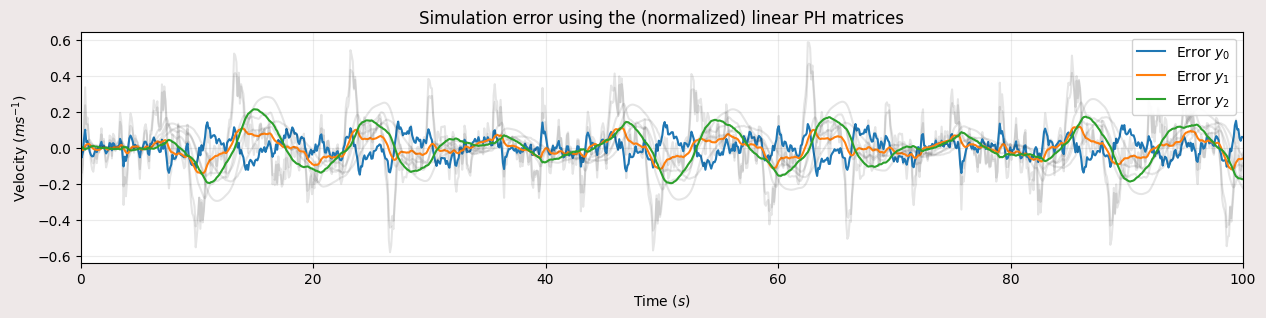

Achieved NRMSE: 0.6367114782333374
Best possible NRMSE: 0.1010897308588028


In [5]:
# Qualitative results of the linear model before training
z=-1
u = datasets[z]["inputs"]   # NB: We are using the first dataset for estimations
comb_states, comb_outputs = simulate_model_withP(sim_time=sim_time, model=combined_model, x0=x0, u_ext=u)
plot_simulation(sim_time, datasets[z]["output"], comb_outputs, plot_mode="error", title="Simulation error using the (normalized) linear PH matrices")
achieved_NRMSE = torch.sqrt(torch.mean(torch.square(comb_outputs - datasets[z]["noisy_output"]))) / torch.std(comb_outputs)
best_possible_NRMSE = torch.sqrt(torch.mean(torch.square(datasets[z]["output"] - datasets[z]["noisy_output"]))) / torch.std(datasets[z]["output"])
print(f"Achieved NRMSE: {achieved_NRMSE}")
print(f"Best possible NRMSE: {best_possible_NRMSE}")

### Train the encoder for 10.000 epochs
- Freeze matrix net parameters
- Train the model with a time window of 1
- Plot training performance
- Plot 1-step ahead predictions

In [6]:
# Turn off training for everything besides the encoder
for name, layer in combined_model.named_children():
    if name == "enc_net":
        for param in layer.parameters():    
            param.requires_grad = True
    else:
        for param in layer.parameters():
            param.requires_grad = False

In [7]:
# Train encoder model parameters
# Import or generate data
if os.path.isfile(PATH_TRAINED_ENC):
    print(f"Loading encoder parameters from: {PATH_TRAINED_ENC}")
    saved_encoder = torch.load(PATH_TRAINED_ENC, weights_only=False)
    print(saved_encoder["state_dict"].items())
else:
    print(f"Generating dataset to: {PATH_TRAINED_ENC}")
    enc_its = 10000
    enc_val_freq = 100
    enc_loss, enc_val_loss, enc_best_sd = fit_model(combined_model, datasets[:5], datasets[5:7], n_its=enc_its, n_future=1, val_freq=enc_val_freq, enc_train=True)
    enc_train = {
        "train_loss":enc_loss, 
        "val_loss":enc_val_loss,
        "state_dict":enc_best_sd
    }
    torch.save(enc_train, PATH_TRAINED_ENC)

Generating dataset to: models/encoders/W33_TEMPSNR_combined_model_encoder.pt


  0%|          | 9/10000 [00:00<03:58, 41.92it/s]

Iteration       0, with training loss (NRMSE): 1.64901 and validation loss (NRMSE): 1.85839 === NEW BEST VALIDATION!


  1%|          | 108/10000 [00:01<02:57, 55.77it/s]

Iteration     100, with training loss (NRMSE): 0.23391 and validation loss (NRMSE): 0.25871 === NEW BEST VALIDATION!


...

 98%|█████████▊| 9809/10000 [02:37<00:03, 50.50it/s]

Iteration   9,800, with training loss (NRMSE): 0.11063 and validation loss (NRMSE): 0.11333


 99%|█████████▉| 9908/10000 [02:39<00:02, 45.99it/s]

Iteration   9,900, with training loss (NRMSE): 0.12247 and validation loss (NRMSE): 0.11226 === NEW BEST VALIDATION!


100%|██████████| 10000/10000 [02:40<00:00, 62.25it/s]


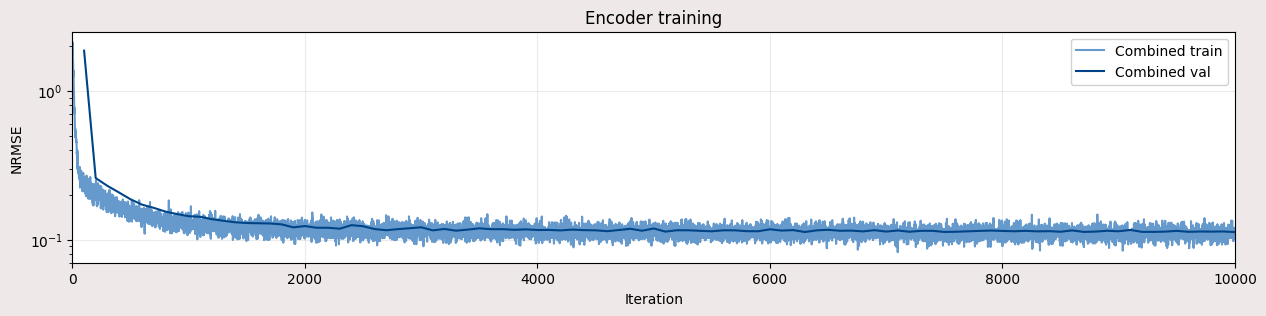

In [8]:
# Plot Encoder training
plt.semilogy(enc_loss, label="Combined train", color="#6699CC")
plt.semilogy(torch.arange(enc_val_freq, enc_its+1, enc_val_freq), enc_val_loss[enc_val_loss.nonzero()], label="Combined val", color="#004488")

plt.ylabel('NRMSE')
plt.legend(loc=1)
plt.xlabel('Iteration')
plt.xlim([0, max(len(enc_loss), len(enc_val_loss))])
plt.title("Encoder training")
plt.grid(alpha=0.25)
plt.show()

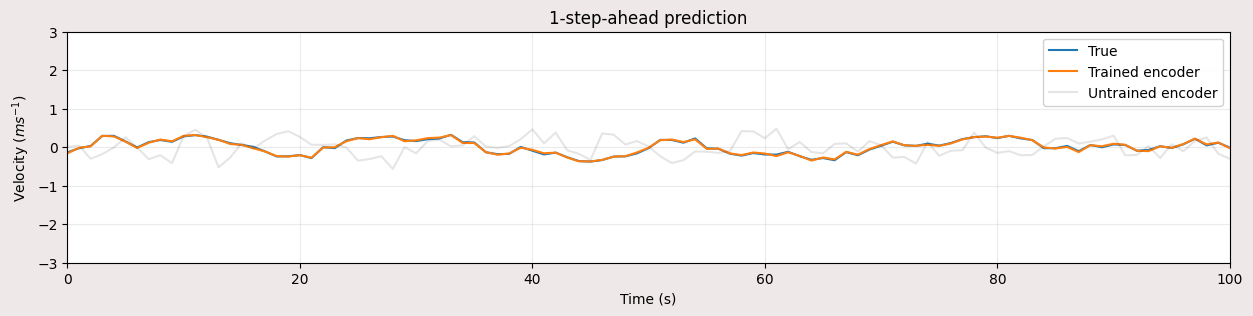

In [9]:
# Plot Encoder performance
untrained_combined_model = combined_PHNN(system_dim, na, nb, dt=sim_time[1], weight=1,
                               Jinit=J,
                               Rinit=R,
                               Ginit=G,
                               Qinit=Q,
                               Pinit=P,
                               custom_kwargs=dict(Jnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True)),
                                                  Rnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True)),
                                                  Gnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True)),
                                                  Hnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True))))

t = 0
arrays = timeseries_splitting(datasets[0], n_past=combined_model.na, n_future=t+1, stride=1) #transform (u, y) into (u1, y1, u2, y2)
u1 = arrays[0]#[0, :, :].view(1, arrays[0].shape[1], arrays[0].shape[2])
y1 = arrays[1]#[0, :, :].view(1, arrays[1].shape[1], arrays[1].shape[2])
u2 = arrays[2]#[0, :, :].view(1, arrays[2].shape[1], arrays[2].shape[2])
y2 = arrays[3][:, t, 0]

# model input must be upast, ypast ufuture
ypred = combined_model(u1, y1, u2).detach().numpy()
untrained_ypred = untrained_combined_model(u1, y1, u2).detach().numpy()
plt.plot(y2, label="True")
plt.plot(ypred[:, t, 0], label="Trained encoder")
plt.plot(untrained_ypred[:, t, 0], "k", alpha=0.1, label="Untrained encoder")
plt.ylim([-3, 3])
plt.xlim([0, sim_time[-1]])
plt.title("1-step-ahead prediction")
plt.ylabel("Velocity ($ms^{-1}$)")
plt.xlabel("Time (s)")
plt.legend(loc=1)
plt.show()

### Train the NNs for <font color='red'>(???)</font> epochs
- Unfreeze matrix NN parameters
- Train the model for <font color='red'>(???)</font> epochs with a time window of <font color='red'>(???)</font>
- Plot training performance
- Plot full simulation predictions

In [10]:
# Unfreeze matrix net parameters
for name, layer in combined_model.named_children():
    if name == "enc_net":
        for param in layer.parameters():
            param.requires_grad = True
    else:
        for param in layer.parameters():
            param.requires_grad = True

In [ ]:
# Train the rest of the model
T_list = [50, 100, 200, 300, 400, 500]
iterations = 200
val_freq = 10
loss = torch.FloatTensor([])
val_loss = torch.FloatTensor([])
best_sd = combined_model.state_dict()
for i, T_i in enumerate(T_list):
    # Run the training steps
    print(f"Start training for window length: {T_i}")
    loss_i, val_loss_i, best_sd_i = fit_model(combined_model, datasets[:5], datasets[5:7], n_its=iterations, n_future=T_i, val_freq=val_freq, lr=1e-3)
    print(f"Best loss for window length {T_i} is: {torch.min(loss_i)} at iteration {torch.argmin(loss_i)}")
    print(f"Best validation loss for window length {T_i} is: {torch.min(val_loss_i[val_loss_i.nonzero()])} at iteration {torch.argmin(val_loss_i[val_loss_i.nonzero()])*max(1, int(iterations/20))}")
    
    # Update and save the training progression
    loss = torch.cat((loss, loss_i), dim=0)
    val_loss = torch.cat((val_loss, val_loss_i), dim=0)
    step_train = {
    "train_loss":loss, 
    "val_loss":val_loss,
    "state_dict":best_sd_i,
    "T_list":T_list,
    "linear_matrices":[E, Q, J, R, G, P, S, N]
    }
    torch.save(step_train, PATH_TRAINED_MODEL[:-3] + "_epoch_" + str(iterations*(i+1)) + ".pt")

Start training for window length: 50


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 1/200 [00:13<43:25, 13.09s/it]

Iteration       0, with training loss (NRMSE): 0.48933 and validation loss (NRMSE): 0.36157 === NEW BEST VALIDATION!


  6%|▌         | 11/200 [00:36<14:41,  4.66s/it]

Iteration      10, with training loss (NRMSE): 0.22302 and validation loss (NRMSE): 0.22401 === NEW BEST VALIDATION!


  6%|▋         | 13/200 [00:38<08:48,  2.83s/it]

C:\Users\20174290\AppData\Local\Temp\ipykernel_12432\226023805.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([0, 1])


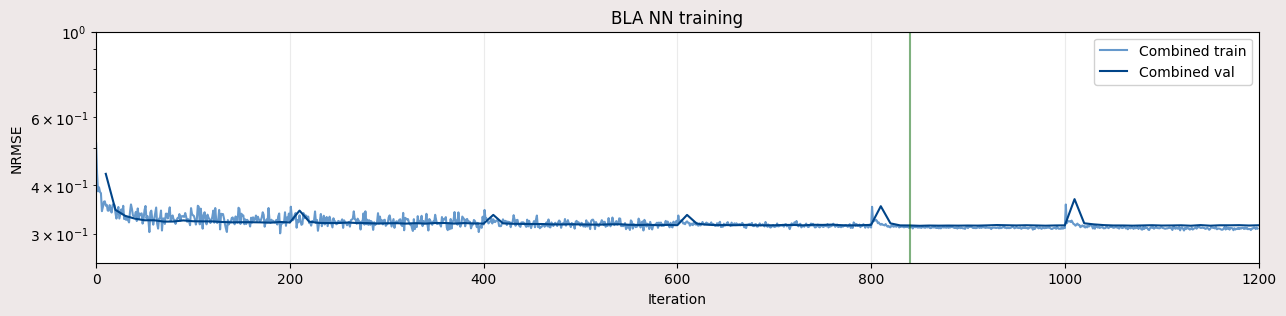

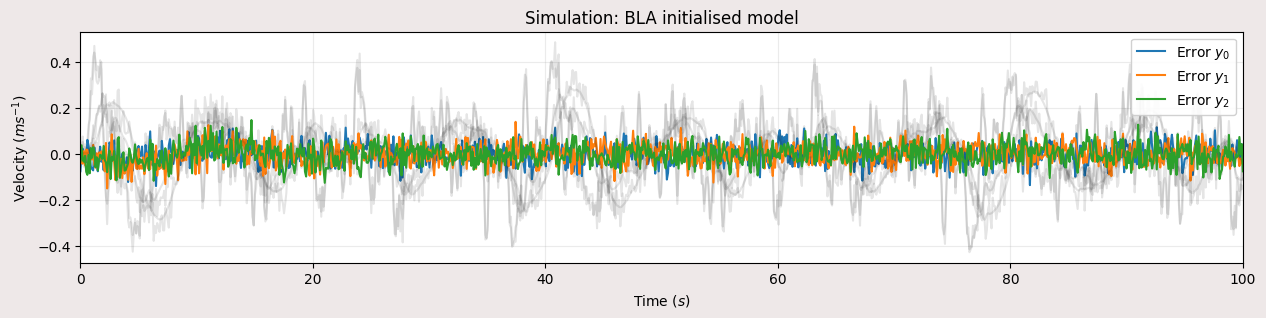

Achieved NRMSE: 0.3313826024532318


In [37]:
## Plot training performance
val_freq = 10
z=-1
plt.semilogy(loss, label="Combined train", color="#6699CC")
plt.semilogy(torch.arange(10, len(T_list)*iterations+val_freq, val_freq), val_loss[val_loss.nonzero()], label="Combined val", color="#004488")
plt.vlines(x=torch.argmin(val_loss[val_loss.nonzero()])*val_freq, ymin=0, ymax=1e10, colors="#006400", alpha=0.5)
plt.ylabel('NRMSE')
plt.legend(loc=1)
plt.xlabel('Iteration')
plt.xlim([0, max(len(loss), len(val_loss))])
plt.ylim([0, 1])
plt.title("BLA NN training")
plt.grid(alpha=0.25)
plt.show()

# Plot qualitative performance
comb_states, comb_outputs = simulate_model_withP(sim_time=sim_time, model=combined_model, x0=x0, u_ext=datasets[z]["inputs"])
plot_simulation(sim_time, datasets[z]["noisy_output"], comb_outputs, plot_mode="error", title="Simulation: BLA initialised model")
achieved_NRMSE = torch.sqrt(torch.mean(torch.square(comb_outputs - datasets[z]["noisy_output"]))) / torch.std(comb_outputs)
print(f"Achieved NRMSE: {achieved_NRMSE}")

### Evaluate learned model performance
- Load fit results
- Check matrices / Rebuild matrices
- Plot training performance
- Plot simulation

In [42]:
# Load fit results
LOAD_DATA = PATH_DATASET
LOAD_ENC = "models/encoders/W33_3SNR_combined_model_encoder.pt"
LOAD_FIT = "models/W33_3SNR_combined_model_epoch_1200.pt"

data_fit = torch.load(LOAD_DATA, weights_only=False)
encoder_fit = torch.load(LOAD_ENC, weights_only=False)
matrix_fit = torch.load(LOAD_FIT, weights_only=False)
#matrix_fit["linear_matrices"] = [E, Q, J, R, G, P, S, N]    # Remove once saved models include the linear matrices
print(matrix_fit.keys())

# Load the model
system_dim = torch.IntTensor([[6, 3]])
na = 10
nb = 10

E_lin, Q_lin, J_lin, R_lin, G_lin, P_lin, S_lin, N_lin = matrix_fit["linear_matrices"]
combined_model = combined_PHNN(system_dim, na, nb, dt=sim_time[1], weight=1,
                               Jinit=J,
                               Rinit=R,
                               Ginit=G,
                               Qinit=Q,
                               Pinit=P)
combined_model.load_state_dict(matrix_fit["state_dict"])

dict_keys(['train_loss', 'val_loss', 'state_dict', 'T_list', 'linear_matrices'])


<All keys matched successfully>

In [43]:
# Check the trained matrices:
xt = torch.rand(1, 6)
xc_dim = torch.sum(system_dim, 0)[0]
sigc_dim = torch.sum(system_dim, 0)[1]
combined_model.load_state_dict(matrix_fit["state_dict"])
J_tr, R_tr, G_tr, dHdx_tr, P_tr = combined_model.get_matrices(xt)
J_tr = J_tr.detach().view(xc_dim, xc_dim)*100
R_tr = R_tr.detach().view(xc_dim, xc_dim)*100
G_tr = G_tr.detach().view(xc_dim, sigc_dim)*100
P_tr = P_tr.detach().view(xc_dim, sigc_dim)*100
dHdx_tr = dHdx_tr.detach().view(xc_dim, 1)/100

if False:   # Check the linear matrices
    plot_PH_matrices(*matrix_fit["linear_matrices"])

if False:   # Check the full trained matrices at state 0
    plot_PH_matrices(Q=dHdx_tr, J=J_tr, R=R_tr, G=G_tr, P=P_tr)

In [63]:
#og_JRQX = torch.einsum("ij, kj -> ik", J-R,torch.einsum("ij, kj -> ik", Q, xt.detach()))
#tr_JRQX = torch.einsum("ij, kj -> ik", J_tr-R_tr, dHdx_tr)
#plot_matrix_heatmap(og_JRQX, "linear (J-R)Qx")
#plot_matrix_heatmap(tr_JRQX, "nonlinear (J-R)dHdx")
#plot_matrix_heatmap(og_JRQX-tr_JRQX, "difference A(x)")


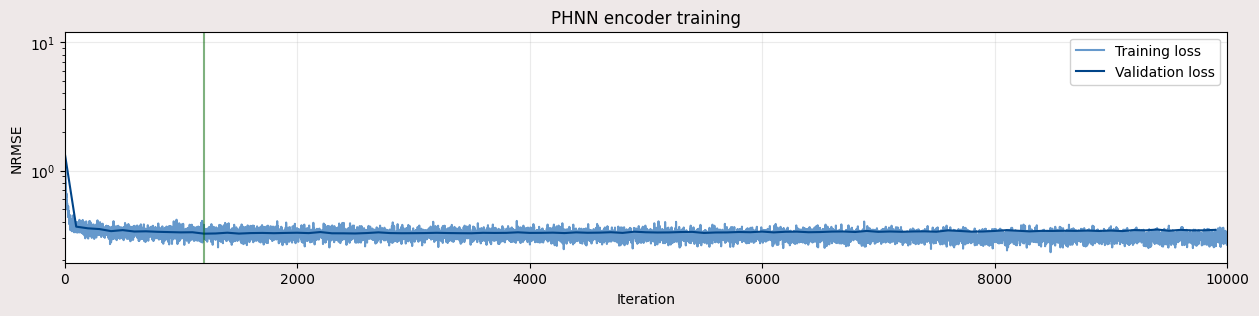

Minimal 1-step ahead NRMSE achieved: 0.32259008288383484 at epoch 1200


In [44]:
# Check the losses during encoder training
enc_val_freq = int(encoder_fit["train_loss"].shape[0] / encoder_fit["val_loss"].nonzero().shape[0])
plt.semilogy(encoder_fit["train_loss"], label="Training loss", color="#6699CC")
plt.semilogy(encoder_fit["val_loss"].nonzero(), encoder_fit["val_loss"][encoder_fit["val_loss"].nonzero()], label="Validation loss", color="#004488")
#plt.vlines(x=torch.argmin(encoder_fit["val_loss"]), ymin=0, ymax=1e10, colors="#006400", alpha=0.25)
plt.vlines(x=torch.argmin(encoder_fit["val_loss"][encoder_fit["val_loss"].nonzero()])*enc_val_freq, ymin=0, ymax=1e10, colors="#006400", alpha=0.5)
plt.ylabel('NRMSE')
plt.legend(loc=1)
plt.xlabel('Iteration')
plt.xlim([0, max(len(encoder_fit["train_loss"]), len(encoder_fit["val_loss"]))])
plt.title(f"PHNN encoder training")
plt.grid(alpha=0.25)
plt.show()

print(f"Minimal 1-step ahead NRMSE achieved: {torch.min(encoder_fit["val_loss"][encoder_fit["val_loss"].nonzero()])} at epoch {enc_val_freq*torch.argmin(encoder_fit["val_loss"][encoder_fit["val_loss"].nonzero()])}")

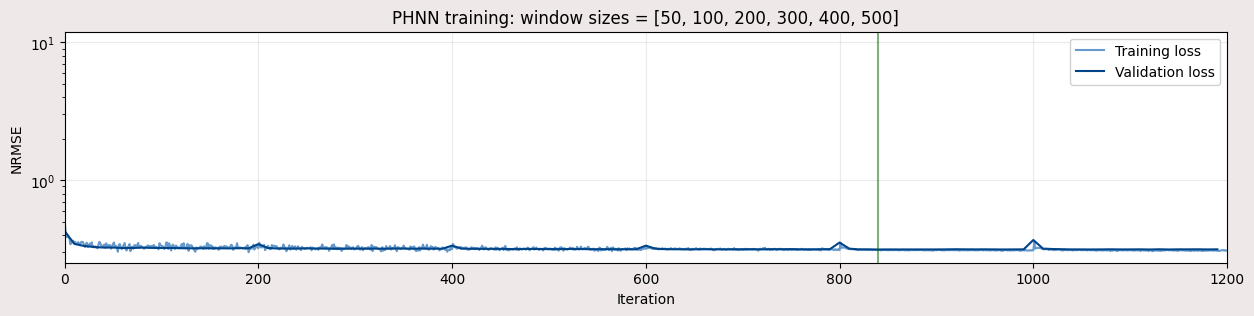

Minimal validation NRMSE achieved: 0.3141776919364929 at epoch 840


In [45]:
# Check the losses during matrix NN training
matrix_val_freq = int(matrix_fit["train_loss"].shape[0] / matrix_fit["val_loss"].nonzero().shape[0])
plt.semilogy(matrix_fit["train_loss"], label="Training loss", color="#6699CC")
plt.semilogy(matrix_fit["val_loss"].nonzero(), matrix_fit["val_loss"][matrix_fit["val_loss"].nonzero()], label="Validation loss", color="#004488")
plt.vlines(x=torch.argmin(matrix_fit["val_loss"][matrix_fit["val_loss"].nonzero()])*matrix_val_freq, ymin=0, ymax=1e10, colors="#006400", alpha=0.5)
plt.ylabel('NRMSE')
plt.legend(loc=1)
plt.xlabel('Iteration')
plt.xlim([0, max(len(matrix_fit["train_loss"]), len(matrix_fit["val_loss"]))])
plt.title(f"PHNN training: window sizes = {matrix_fit["T_list"]}")
plt.grid(alpha=0.25)
plt.show()

print(f"Minimal validation NRMSE achieved: {torch.min(matrix_fit["val_loss"][matrix_fit["val_loss"].nonzero()])} at epoch {torch.argmin(matrix_fit["val_loss"][matrix_fit["val_loss"].nonzero()])*10}")

In [46]:
# Compare performance of the linear and nonlinear models
untrained_model = combined_PHNN(system_dim, na, nb, dt=sim_time[1], weight=1,
                               Jinit=J,
                               Rinit=R,
                               Ginit=G,
                               Qinit=Q,
                               Pinit=P,
                               custom_kwargs=dict(Jnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True)),
                                                  Rnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True)),
                                                  Gnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True)),
                                                  Hnet_kwargs=dict(net_kwargs=dict(initial_output_is_zero=True))))
untrained_model.load_state_dict(encoder_fit["state_dict"])

# Run the simulations on the test set
z = -1
n_samples = data_fit[z]["inputs"].shape[0]
max_future = n_samples-na
u1_test, y1_test, u2_test, y2_test = timeseries_splitting(data=data_fit[z], n_past=na, n_future=max_future)
ypred_test = combined_model(u1_test, y1_test, u2_test).detach()[0, :, :]
ylin_test = untrained_model(u1_test, y1_test, u2_test).detach()[0, :, :]

# Check the NRMSE's
achieved_NRMSE = torch.sqrt(torch.mean(torch.square(y2_test - ypred_test))) / torch.std(y2_test)
achieved_lin_NRMSE = torch.sqrt(torch.mean(torch.square(y2_test - ylin_test))) / torch.std(y2_test)
print(f"Achieved NRMSE: {achieved_NRMSE}")
print(f"Achieved linear NRMSE: {achieved_lin_NRMSE}")

Achieved NRMSE: 0.3181424140930176
Achieved linear NRMSE: 0.5661838054656982


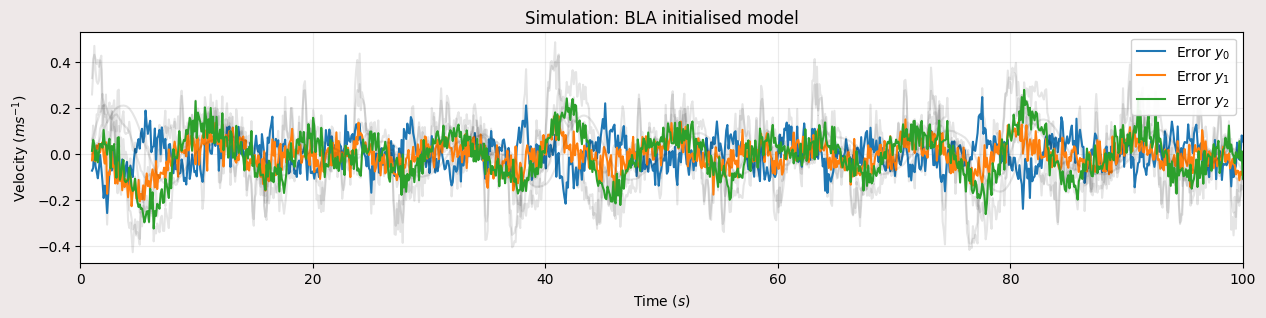

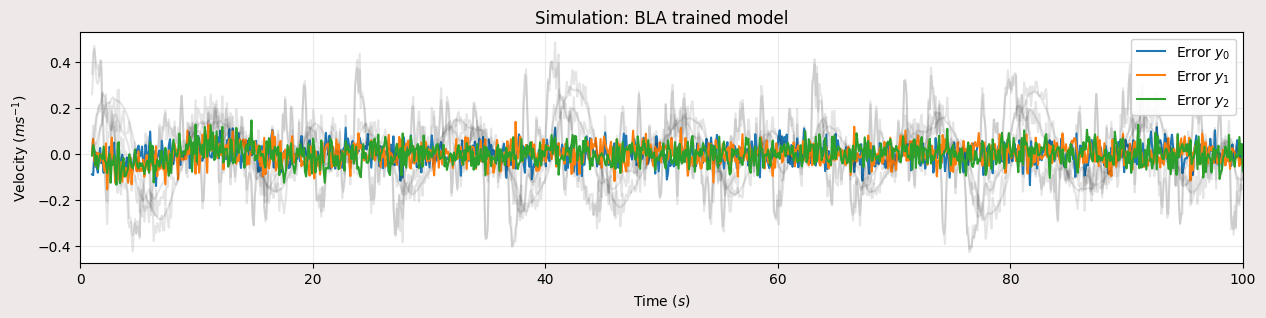

In [51]:
# Plot the simulations
plot_simulation(sim_time[na:], true_outputs=y2_test[0, :, :], sim_outputs=ylin_test, plot_mode="error", title="Simulation: BLA initialised model")
plot_simulation(sim_time[na:], true_outputs=y2_test[0, :, :], sim_outputs=ypred_test, plot_mode="error", title="Simulation: BLA trained model")

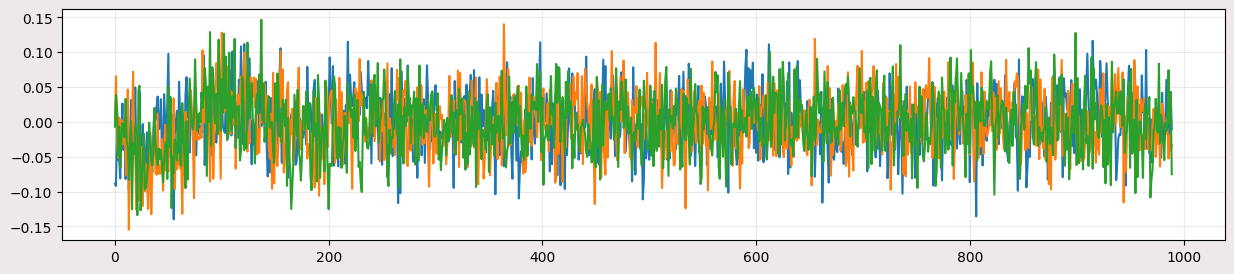

In [48]:
# Seems to be bad transient effect?
plt.plot(y2_test[0, :, :]-ypred_test)

In [53]:
perfect_NRMSE

tensor(0.3186)

In [52]:
# Report performance statistics
perfect_NRMSE = torch.sqrt(torch.mean(torch.square(data_fit[z]["output"] - data_fit[z]["noisy_output"]))) / torch.std(data_fit[z]["output"])
min_val_loss = torch.min(matrix_fit["val_loss"][matrix_fit["val_loss"].nonzero()])
min_train_loss = torch.min(matrix_fit["train_loss"])

print(f"For a dataset with SNR = {1/perfect_NRMSE} [{torch.round(20*torch.log10(1/perfect_NRMSE))} dB]")
print(f"Best training loss = {min_train_loss}")
print(f"Best validation loss = {min_val_loss}")
print(f"Best test loss = {achieved_NRMSE}")


For a dataset with SNR = 3.1390151977539062 [10.0 dB]
Best training loss = 0.3003692626953125
Best validation loss = 0.3141776919364929
Best test loss = 0.3181424140930176


### (Appendix) Dataset visualisations:

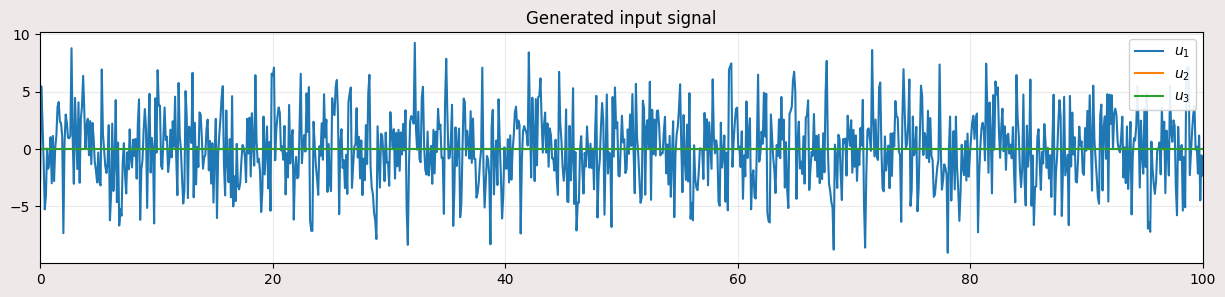

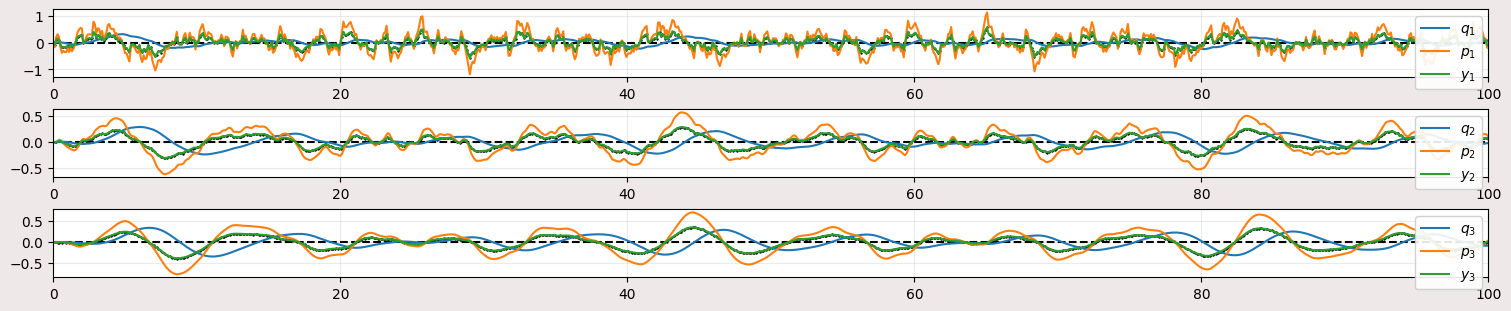

In [164]:
# Check the dataset
nsys=3
z = -1 # Select which dataset should be used for plotting
inputs = datasets[z]["inputs"]
states = datasets[z]["states"]
output = datasets[z]["output"]
if "noisy_output" in datasets[z]:   # Check if the dataset is generated with noise
    noisy_output = datasets[z]["noisy_output"]
else:
    print("No noisy output present in the dataset")

# Plot the system behaviour
fig_input = plt.figure(figsize=(15, 3))
plt.plot(sim_time, inputs)
plt.legend([f"$u_{1}$", f"$u_{2}$", f"$u_{3}$"], loc=1)
plt.title("Generated input signal")
plt.xlim([0, max(sim_time)])         


fig, (ax0, ax1, ax2) = plt.subplots(nsys, 1, layout='constrained') #TODO, automate ax1, ax2, ax3
for i in range(0, nsys):
    # globals()["ax%s" % i] basically says "axi" for looped plotting
    globals()["ax%s" % i].plot(sim_time, torch.zeros_like(sim_time), "k--",label='_nolegend_')  # Plot 0-line
    globals()["ax%s" % i].plot(sim_time, states[:, i])                                          # Plot state q_i
    globals()["ax%s" % i].plot(sim_time, states[:, nsys+i])                                     # Plot state p_i
    globals()["ax%s" % i].plot(sim_time, output[:, i])                                          # Plot output y_i
    if noisy_output is not None:
        globals()["ax%s" % i].scatter(sim_time, noisy_output[:, i], s=0.5, color="black")       # Plot noisy outputs y_1
    globals()["ax%s" % i].legend([f'$q_{i+1}$', f'$p_{i+1}$', f'$y_{i+1}$'], loc=1)             # Add legends
    globals()["ax%s" % i].set_xlim([0, max(sim_time)])                                          # Set xlimits
plt.show()

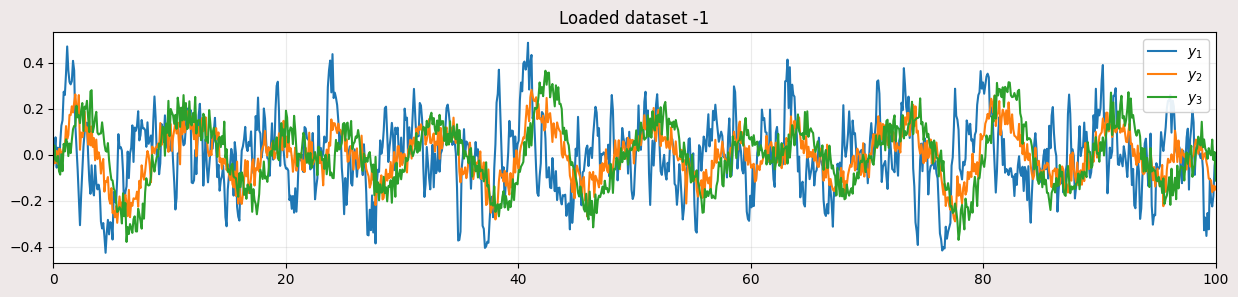

In [8]:
z = -1
plt.plot(sim_time, datasets[z]["noisy_output"][:, 0])
plt.plot(sim_time, datasets[z]["noisy_output"][:, 1])
plt.plot(sim_time, datasets[z]["noisy_output"][:, 2])
plt.legend(["$y_{1}$", "$y_{2}$", "$y_{3}$"], loc=1)
plt.title(f"Loaded dataset {z}")
plt.xlim([0, sim_time[-1]])
plt.show()